Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Loading the dataset

In [2]:
df=pd.read_csv('titanic.csv')

Show first five rows

In [3]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Overall survival distribution

In [ ]:
# Find the data type of the dataset object shows that data is of categorical and int, float, data type shows numerical data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Check for the missing values step 2 is to check messiness of data


In [9]:
missing=df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
dtype: int64

1) Univariate analysis on Survived column to find the overall distribution

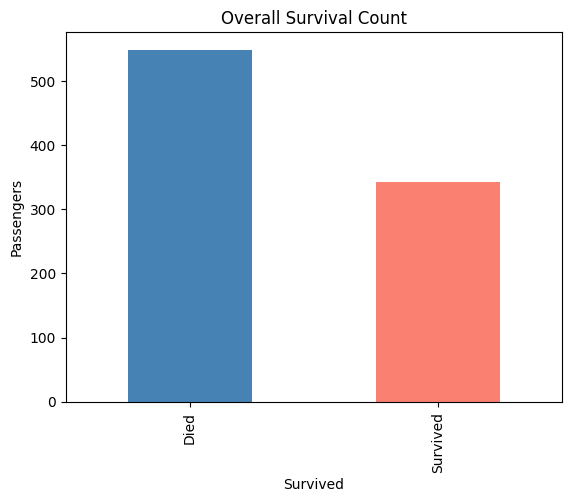

In [5]:
df['Survived'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])

plt.xticks([0,1],['Died','Survived'])
plt.title("Overall Survival Count")
plt.ylabel("Passengers")
plt.show()

Story: What we can see from the overall dataset is more people died overall than they survived

2) Survival by Gender distribution. Finding out who was most likely and least likely to survive

Survived vs sex

We are doing bivariate analysis on sex it should be categorical binary data and survived then we can 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


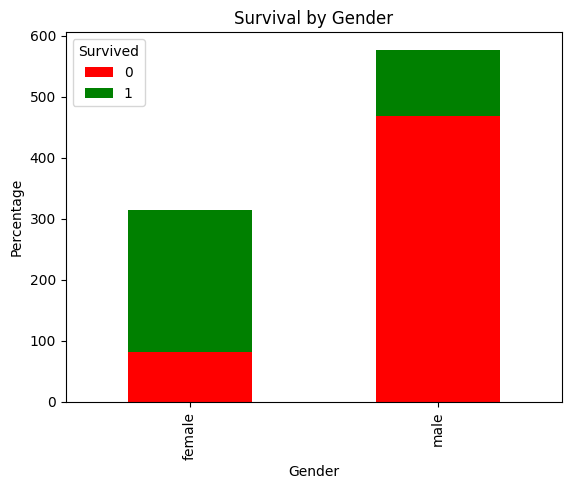

In [12]:
ct = pd.crosstab(df['Sex'],df['Survived'])

ct.plot(kind='bar',stacked=True,color=['red','green'])

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.show()

Insights:
We can see from stacked bar 0 represent dead and 1 represents survived. From figure, we see that female had higher survival rate and if someone is male survival chances are very low. We found out female  were much more likely to survive than male.


Survivor by Passenger class. Pclass is label so its categorical value even though it says int. A trick to find this is can we say class average is 2.4 no. It is ordinal categorical value

so again since dataset are categorical lets use stacked bar 

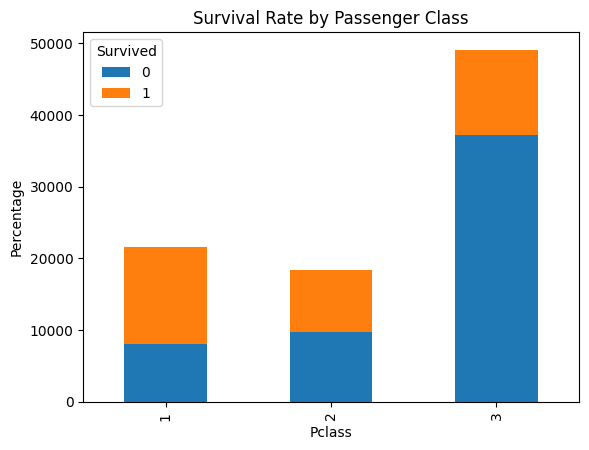

In [15]:
class_survival = pd.crosstab(df['Pclass'],df['Survived'])*100

class_survival.plot(kind='bar',stacked=True)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Percentage")

plt.show()

In [16]:
class_survived=(df.groupby('Pclass')['Survived'].mean()*100).round(1)
print(class_survived)

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


Insights:
We can see that the first class passenger has the highest survival rate. 

Final Insights:
Based on the analysis,the passengers most likely to survive were female passengers travelling in First class and the passengers least likely to survive were male travelling in third class.